Number of printable mixes: 64


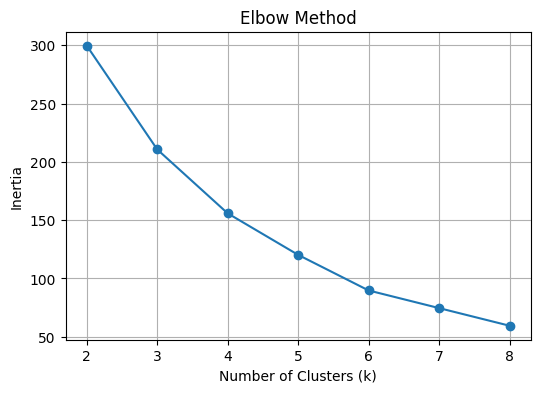


Silhouette Scores
k = 2 | silhouette = 0.347
k = 3 | silhouette = 0.436
k = 4 | silhouette = 0.474
k = 5 | silhouette = 0.490
k = 6 | silhouette = 0.531
k = 7 | silhouette = 0.550
k = 8 | silhouette = 0.574

Best k = 8
Best silhouette = 0.574

Cluster Sizes
Cluster
0     3
1    10
2     8
3     5
4    14
5    10
6     3
7    11
Name: count, dtype: int64

Cluster Summary
         Water/Binder Ratio  Cement  Fly Ash  Silica Fume  Fine Aggregate  \
Cluster                                                                     
0                      0.35  424.33   638.33        39.33         1060.00   
1                      0.50  597.90     0.00         0.00         1229.50   
2                      0.34  961.46     0.00         9.24          957.61   
3                      0.29  579.00   165.00        83.00         1241.00   
4                      0.38  636.10   202.58        54.38          882.58   
5                      0.32  636.30   165.40        24.60         1239.10   
6         

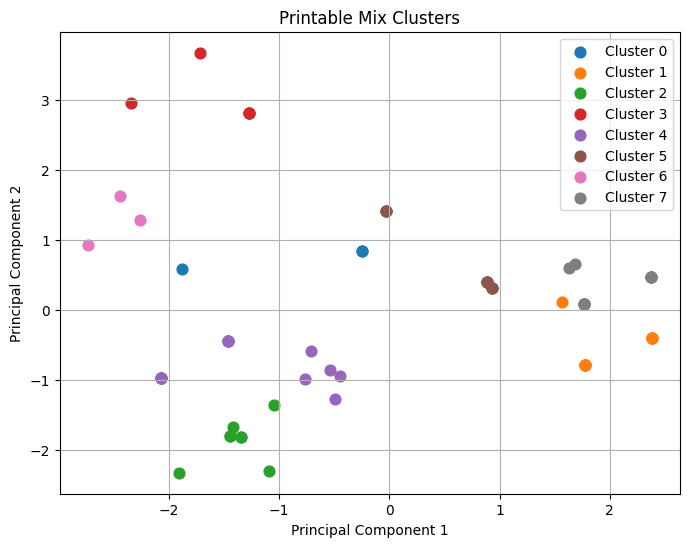


Clustered dataset saved as:
Printable_Mixes_With_Clusters.csv

Cluster Sizes (k=4)
Cluster_4
0    28
1    17
2    11
3     8
Name: count, dtype: int64

Cluster Summary (k=4)
           Water/Binder Ratio  Cement  Fly Ash  Silica Fume  Fine Aggregate  \
Cluster_4                                                                     
0                        0.46  544.04   109.79         0.00         1221.61   
1                        0.38  598.73   279.47        51.73          913.89   
2                        0.27  633.45   119.73        83.60         1236.30   
3                        0.34  961.46     0.00         9.24          957.61   

           Superplasticizer  Fiber Volume Fraction  
Cluster_4                                           
0                      0.16                   0.19  
1                      0.19                   0.00  
2                      0.77                   0.12  
3                      0.24                   0.00  


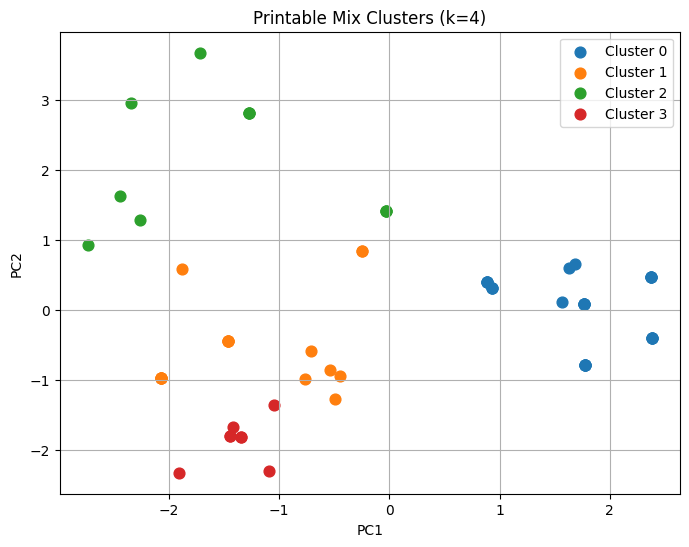


Cluster Sizes (k=5)
Cluster_5
0    10
1    17
2     8
3     8
4    21
Name: count, dtype: int64

Cluster Summary (k=5)
           Water/Binder Ratio  Cement  Fly Ash  Silica Fume  Fine Aggregate  \
Cluster_5                                                                     
0                        0.32  636.30   165.40        24.60         1239.10   
1                        0.38  598.73   279.47        51.73          913.89   
2                        0.34  961.46     0.00         9.24          957.61   
3                        0.25  655.75   103.12        84.20         1239.00   
4                        0.50  504.38    91.05         0.00         1214.48   

           Superplasticizer  Fiber Volume Fraction  
Cluster_5                                           
0                      0.16                   0.22  
1                      0.19                   0.00  
2                      0.24                   0.00  
3                      1.00                   0.08  
4       

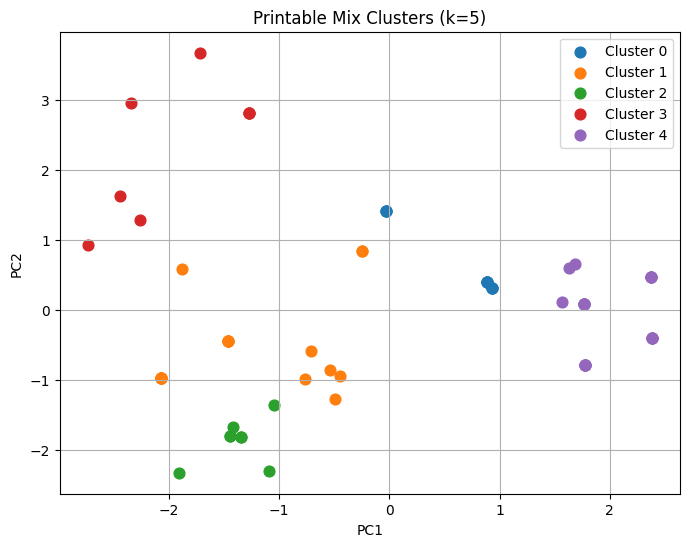

In [1]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ============================================
# LOAD DATA
# ============================================

df = pd.read_csv("rheology dataset(Printability cluster) 1.csv")

# Remove unnamed columns if present
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# Convert Printable column
df["Printable"] = df["Printable"].map({
    "Yes": 1,
    "No": 0
})

# ============================================
# KEEP ONLY PRINTABLE MIXES
# ============================================

printable_df = df[df["Printable"] == 1].copy()

print("Number of printable mixes:", len(printable_df))

# ============================================
# FEATURES FOR CLUSTERING
# ============================================

features_cluster = [
    "Water/Binder Ratio",
    "Cement",
    "Fly Ash",
    "Silica Fume",
    "Fine Aggregate",
    "Superplasticizer",
    "Fiber Volume Fraction"
]

# ============================================
# HANDLE MISSING VALUES
# ============================================

X = printable_df[features_cluster]

X = X.fillna(X.median())

# ============================================
# STANDARDIZE DATA
# ============================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ============================================
# ELBOW METHOD
# ============================================

inertia = []

for k in range(2, 9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))

plt.plot(
    range(2,9),
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

# ============================================
# SILHOUETTE SCORES
# ============================================

print("\nSilhouette Scores")

best_k = None
best_score = -1

for k in range(2,9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(
        f"k = {k} | silhouette = {score:.3f}"
    )

    if score > best_score:

        best_score = score
        best_k = k

print("\nBest k =", best_k)
print("Best silhouette =", round(best_score,3))

# ============================================
# FINAL KMEANS MODEL
# ============================================

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

printable_df["Cluster"] = kmeans.fit_predict(
    X_scaled
)

# ============================================
# CLUSTER SIZE
# ============================================

print("\nCluster Sizes")

print(
    printable_df["Cluster"]
    .value_counts()
    .sort_index()
)

# ============================================
# CLUSTER SUMMARY
# ============================================

cluster_summary = (
    printable_df
    .groupby("Cluster")[features_cluster]
    .mean()
    .round(2)
)

print("\nCluster Summary")

print(cluster_summary)

# ============================================
# PCA FOR VISUALIZATION
# ============================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("\nExplained Variance Ratio")

print(
    pca.explained_variance_ratio_
)

print(
    "Total Variance Explained:",
    round(
        pca.explained_variance_ratio_.sum(),
        3
    )
)

# ============================================
# PCA PLOT
# ============================================

plt.figure(figsize=(8,6))

for cluster in sorted(
    printable_df["Cluster"].unique()
):

    idx = printable_df["Cluster"] == cluster

    plt.scatter(
        X_pca[idx,0],
        X_pca[idx,1],
        label=f"Cluster {cluster}",
        s=60
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("Printable Mix Clusters")

plt.legend()

plt.grid(True)

plt.show()

# ============================================
# SAVE RESULTS
# ============================================

printable_df.to_csv(
    "Printable_Mixes_With_Clusters.csv",
    index=False
)

print(
    "\nClustered dataset saved as:"
)
print(
    "Printable_Mixes_With_Clusters.csv"
)


# ============================================
# K = 4 CLUSTER ANALYSIS
# ============================================

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

kmeans_4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

printable_df["Cluster_4"] = kmeans_4.fit_predict(X_scaled)

# Cluster sizes
print("\nCluster Sizes (k=4)")
print(
    printable_df["Cluster_4"]
    .value_counts()
    .sort_index()
)

# Cluster summary
cluster_summary_4 = (
    printable_df
    .groupby("Cluster_4")[features_cluster]
    .mean()
    .round(2)
)

print("\nCluster Summary (k=4)")
print(cluster_summary_4)

# PCA Visualization

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

for cluster in sorted(
    printable_df["Cluster_4"].unique()
):

    idx = printable_df["Cluster_4"] == cluster

    plt.scatter(
        X_pca[idx,0],
        X_pca[idx,1],
        label=f"Cluster {cluster}",
        s=60
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Printable Mix Clusters (k=4)")

plt.legend()

plt.grid(True)

plt.show()


# ============================================
# K = 5 CLUSTER ANALYSIS
# ============================================

kmeans_5 = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=20
)

printable_df["Cluster_5"] = kmeans_5.fit_predict(X_scaled)

# Cluster sizes
print("\nCluster Sizes (k=5)")
print(
    printable_df["Cluster_5"]
    .value_counts()
    .sort_index()
)

# Cluster summary
cluster_summary_5 = (
    printable_df
    .groupby("Cluster_5")[features_cluster]
    .mean()
    .round(2)
)

print("\nCluster Summary (k=5)")
print(cluster_summary_5)

# PCA Visualization

plt.figure(figsize=(8,6))

for cluster in sorted(
    printable_df["Cluster_5"].unique()
):

    idx = printable_df["Cluster_5"] == cluster

    plt.scatter(
        X_pca[idx,0],
        X_pca[idx,1],
        label=f"Cluster {cluster}",
        s=60
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Printable Mix Clusters (k=5)")

plt.legend()

plt.grid(True)

plt.show()